# Tabu Search 禁忌搜索

## 本 Notebook 的教学目标

1. 在经典 TSP 场景下理解该算法的工作机制。
2. 完成一个从零实现版本，而不是只调用现成库。
3. 通过路径图、收敛曲线、统计结果观察算法行为。
4. 为下个月授课准备可直接展示的实验材料。

## 为什么选 TSP

禁忌搜索很适合放在 TSP 上讲，因为“邻域移动”“短期记忆”和“避免来回震荡”都能在路径变化中直接观察到。

TSP 的优点是：**结果是可视化路径，过程也是可视化路径**。因此它非常适合课堂讲解组合优化算法。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

# 统一图表风格，保证不同 Notebook 的视觉体验一致。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 为了让路径图更直观，这里统一生成二维城市坐标。

def make_cities(n_cities=20, seed=7):
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 100, size=(n_cities, 2))


def pairwise_distances(cities):
    diff = cities[:, None, :] - cities[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def route_length(route, distance_matrix):
    rolled = np.roll(route, -1)
    return float(distance_matrix[route, rolled].sum())


def plot_route(cities, route, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    ordered = cities[route]
    closed = np.vstack([ordered, ordered[0]])
    ax.plot(closed[:, 0], closed[:, 1], '-o', color='#1f77b4', lw=2, ms=6)
    for idx, (x, y) in enumerate(cities):
        ax.text(x + 1, y + 1, str(idx), fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    return ax


def two_opt_swap(route, i, j):
    new_route = route.copy()
    new_route[i:j] = route[i:j][::-1]
    return new_route


def random_route(rng, n_cities):
    return rng.permutation(n_cities)


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# 固定城市坐标，保证不同算法 Notebook 之间有可比性。
cities = make_cities(n_cities=20, seed=11)
distance_matrix = pairwise_distances(cities)

## 算法直觉

核心思想：每一步都在邻域中选最优候选，但会用禁忌表记录最近做过的移动，避免算法在几个局部结构之间反复来回。

在讲课时，可以把这个算法与“纯贪心”或“纯随机搜索”对照起来讲，学生更容易抓住重点。

In [2]:
def sampled_neighbors(route, rng, n_samples=80):
    # 用采样的方式构造候选邻域，避免每次都枚举全部 2-opt 变换。
    neighbors = []
    n = len(route)
    for _ in range(n_samples):
        i, j = sorted(rng.choice(np.arange(1, n), size=2, replace=False))
        neighbor = two_opt_swap(route, i, j)
        neighbors.append((neighbor, (i, j)))
    return neighbors


def tabu_search(distance_matrix, n_iterations=180, tabu_tenure=12, seed=0):
    rng = np.random.default_rng(seed)
    current = random_route(rng, len(distance_matrix))
    current_length = route_length(current, distance_matrix)
    best = current.copy()
    best_length = current_length

    tabu_list = deque(maxlen=tabu_tenure)
    current_lengths = [current_length]
    best_lengths = [best_length]
    snapshots = [(0, current.copy())]

    for iteration in range(1, n_iterations + 1):
        candidates = sampled_neighbors(current, rng)
        best_candidate = None
        best_candidate_length = np.inf
        best_move = None

        # 禁忌搜索不是随机接受，而是在候选集中找“当前最值得走的一步”。
        for candidate, move in candidates:
            candidate_length = route_length(candidate, distance_matrix)
            is_tabu = move in tabu_list
            aspiration = candidate_length < best_length
            if (not is_tabu or aspiration) and candidate_length < best_candidate_length:
                best_candidate = candidate
                best_candidate_length = candidate_length
                best_move = move

        current = best_candidate
        current_length = best_candidate_length
        tabu_list.append(best_move)

        if current_length < best_length:
            best = current.copy()
            best_length = current_length

        current_lengths.append(current_length)
        best_lengths.append(best_length)

        if iteration in {1, 10, 30, 60, 120, 180}:
            snapshots.append((iteration, current.copy()))

    return {
        'best_route': best,
        'best_length': float(best_length),
        'current_lengths': np.array(current_lengths),
        'best_lengths': np.array(best_lengths),
        'snapshots': snapshots,
    }

## 单次实验演示

下面先做一次完整实验。建议课堂上先关注：

1. 初始路径和最终路径差别有多大。
2. 收敛过程中是否存在明显跳跃。
3. 算法是否会在早期快速改进、后期缓慢收敛。

best route length: 388.2


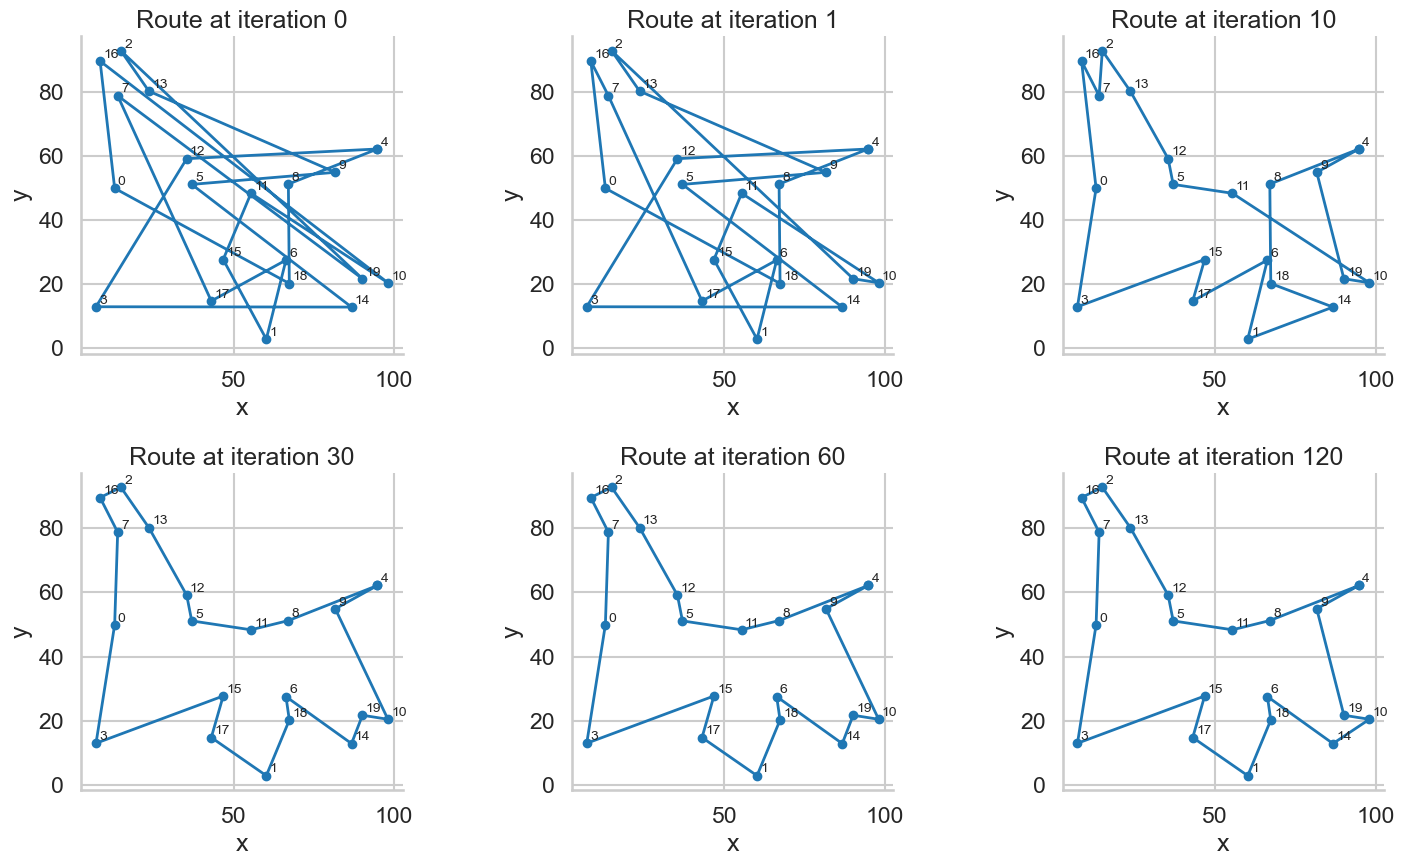

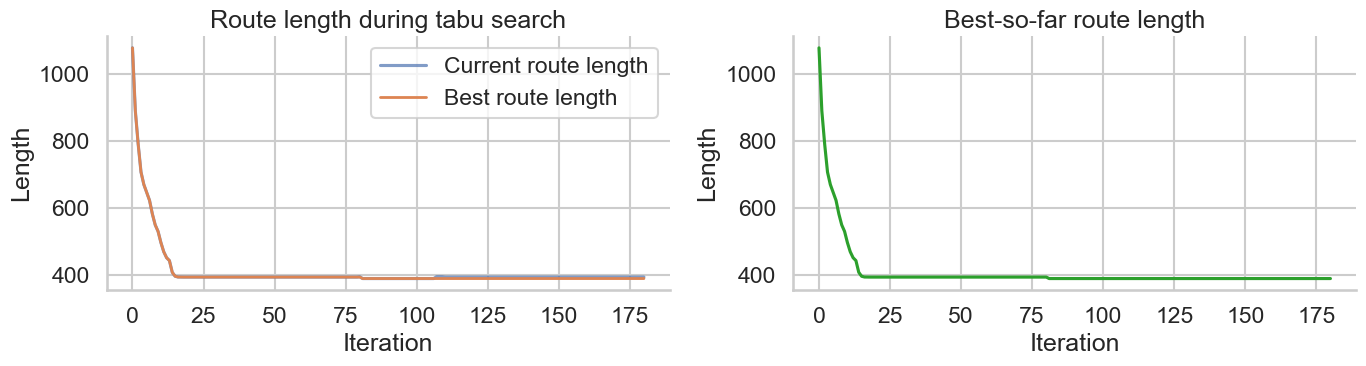

<Figure size 700x700 with 0 Axes>

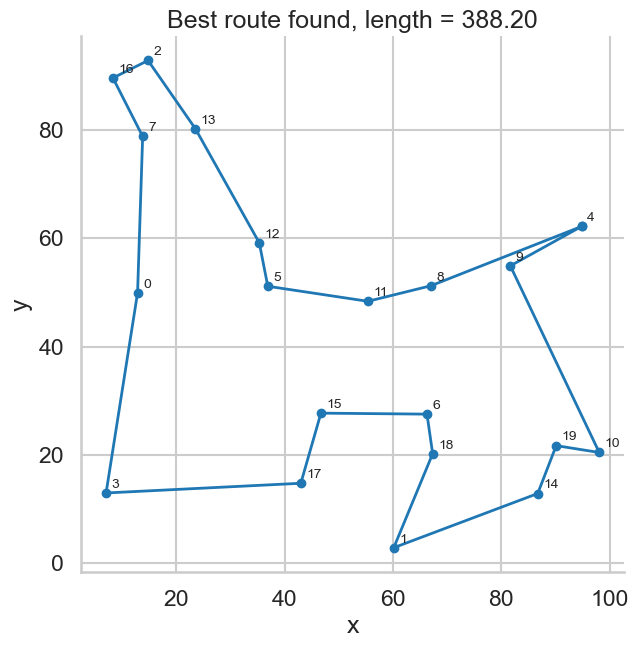

In [3]:
tabu_result = tabu_search(distance_matrix, seed=12)
print('best route length:', round(tabu_result['best_length'], 3))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (iteration, route) in zip(axes.ravel(), tabu_result['snapshots']):
    plot_route(cities, route, f'Route at iteration {iteration}', ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(tabu_result['current_lengths'], alpha=0.7, label='Current route length')
axes[0].plot(tabu_result['best_lengths'], lw=2, label='Best route length')
axes[0].set_title('Route length during tabu search')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Length')
axes[0].legend()

axes[1].plot(np.minimum.accumulate(tabu_result['current_lengths']), color='tab:green')
axes[1].set_title('Best-so-far route length')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Length')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plot_route(cities, tabu_result['best_route'], f'Best route found, length = {tabu_result["best_length"]:.2f}')
plt.show()

## 多次运行与参数分析

组合优化算法往往带有随机性，因此只看一次结果不够。这里用多次实验和参数敏感性分析来说明算法的稳定性与可调节性。

,Tabu Search statistics
best,377.110676
mean,418.126702
worst,466.411747
std,25.332768


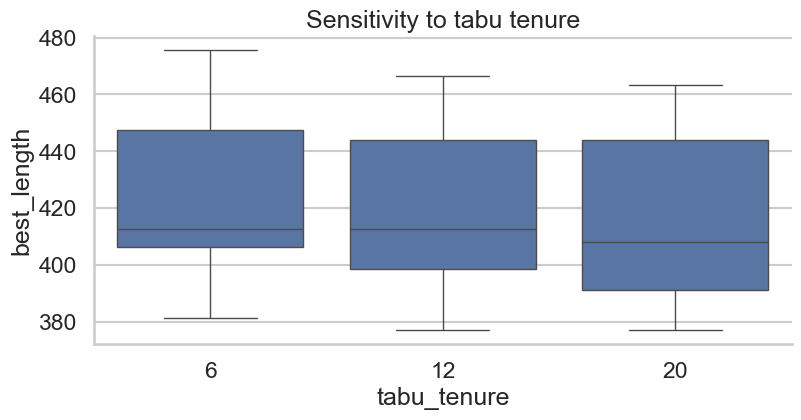

In [4]:
run_scores = [tabu_search(distance_matrix, seed=seed)['best_length'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='Tabu Search statistics'))

tabu_tenures = [6, 12, 20]
records = []
for tabu_tenure in tabu_tenures:
    for seed in range(10):
        best_length = tabu_search(distance_matrix, tabu_tenure=tabu_tenure, seed=seed)['best_length']
        records.append({'tabu_tenure': tabu_tenure, 'best_length': best_length})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='tabu_tenure', y='best_length')
plt.title('Sensitivity to tabu tenure')
plt.show()

## 课堂总结

讲这一类 TSP 实验时，可以让学生反复回答三个问题：

1. 新路径是怎样产生的。
2. 更差的路径何时会被接受，或为什么永远不被接受。
3. 算法如何在“探索新结构”和“保留好结构”之间权衡。